# 2025 CITS4012 Project

# Readme
All the files required to run the code need to be placed in the same path

# Introduction

## Objective
Build and compare compact neural models for **Natural Language Inference (NLI)**. Given a *premise* and a *hypothesis*, the models predict one of two labels: **neutral** or **entails**.

## Data
Three JSON splits are used:
- **Train**: primary source for learning
- **Validation**: model selection and tuning
- **Test**: final, held-out evaluation

Each example contains `premise`, `hypothesis`, and `label`.







# 1.Dataset Processing

## Setup + config

**Purpose**  
Initialize the runtime and shared settings used throughout the notebook.

**What this cell does**  
- Sets random seeds for reproducibility (Python, NumPy, PyTorch)  
- Selects the compute device (CUDA / MPS / CPU) and prints it  
- Defines dataset file paths (train / validation / test)  
- Establishes special tokens (`<pad>`, `<unk>`, `<sep>`) and label mapping  
- Specifies base hyperparameters (max lengths, batch size)

**Notes**  
- This cell does not read or modify any data.  
- All later sections rely on the constants defined here (paths, token IDs, lengths).


In [3]:
# ========== 1) SETUP & CONFIG ==========
from pathlib import Path
from collections import Counter
import json, math, random, re, html, unicodedata
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
import matplotlib.pyplot as plt

# ------------------
# Reproducibility
# ------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# (optional but helpful for determinism on GPU)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ------------------
# Device
# ------------------
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Using device:", device)

# ------------------
# Paths
# ------------------
DATA_DIR = Path('.')  # put the three json files next to the notebook
TRAIN_FP = DATA_DIR / 'train.json'
VAL_FP   = DATA_DIR / 'validation.json'
TEST_FP  = DATA_DIR / 'test.json'

# ------------------
# Special tokens
# ------------------
PAD_TOKEN = '<pad>'
UNK_TOKEN = '<unk>'
SEP_TOKEN = '<sep>'

# ------------------
# Basic config
# ------------------
MAX_LEN_PREMISE    = 64     # truncate long premises
MAX_LEN_HYPOTHESIS = 32
MIN_FREQ           = 2      # min token freq to enter vocab
BATCH_SIZE         = 64

# ------------------
# Labels (fixed order for consistency)
# ------------------
LABEL2ID = {'neutral': 0, 'entails': 1}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}


Using device: cuda


## Load dataset splits

**Purpose**  
Read the JSON splits into memory in a deterministic and schema-checked way.

This cell execute the following processes:
- Loads `train.json`, `validation.json`, and `test.json`  
- Verifies required fields: `premise`, `hypothesis`, `label`  
- Sorts example IDs deterministically (numeric when possible)  
- Drops incomplete examples and reports a warning (count of dropped items)  
- Produces a list of `(premise, hypothesis, label)` triples for each split



In [4]:
# ========== 2) LOAD SPLITS ==========
def _safe_sorted_keys(d):
    """
    Return keys sorted numerically when possible, else lexicographically.
    This keeps example order deterministic across runs.
    """
    def to_intable(k):
        try:
            return int(k), True
        except Exception:
            return k, False

    # Try numeric sort if all keys are int-like
    converted = [to_intable(k) for k in d.keys()]
    all_intlike = all(flag for _, flag in converted)
    if all_intlike:
        return [str(x[0]) for x in sorted(converted, key=lambda t: t[0])]
    # Fallback to plain lexicographic
    return sorted(d.keys(), key=lambda x: (len(str(x)), str(x)))

def load_split(fp: Path):
    """
    Return a list of (premise, hypothesis, label_str) from the course JSON format.
    - Deterministic order (sorted keys)
    - Non-fatal checks: warn if any fields are missing
    """
    with open(fp, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Basic schema checks
    for k in ("premise", "hypothesis", "label"):
        if k not in data or not isinstance(data[k], dict):
            raise ValueError(f"{fp.name}: expected key '{k}' to be a dict")

    prem_d = data["premise"]
    hyp_d  = data["hypothesis"]
    lab_d  = data["label"]

    keys = _safe_sorted_keys(prem_d)
    # Ensure all fields share the same ids; warn if not
    prem_ids = set(prem_d.keys())
    hyp_ids  = set(hyp_d.keys())
    lab_ids  = set(lab_d.keys())
    all_ids  = prem_ids & hyp_ids & lab_ids
    if (prem_ids ^ hyp_ids) or (prem_ids ^ lab_ids):
        missing_p = len(all_ids - prem_ids)
        missing_h = len(all_ids - hyp_ids)
        missing_l = len(all_ids - lab_ids)
        print(f"[WARN] {fp.name}: id set mismatch "
              f"(drop missing) — missing prem={missing_p}, hyp={missing_h}, lab={missing_l}")
        # constrain keys to common ids only (sorted deterministically)
        keys = [k for k in keys if k in all_ids]

    triples = []
    dropped = 0
    for k in keys:
        p = prem_d.get(k, None)
        h = hyp_d.get(k, None)
        l = lab_d.get(k, None)
        if p is None or h is None or l is None:
            dropped += 1
            continue
        triples.append((p, h, l))

    if dropped:
        print(f"[WARN] {fp.name}: dropped {dropped} incomplete examples")

    return triples

train_data = load_split(TRAIN_FP)
val_data   = load_split(VAL_FP)
test_data  = load_split(TEST_FP)

print(f"Loaded: train={len(train_data)}, val={len(val_data)}, test={len(test_data)}")
if len(train_data) > 0:
    print("Example (train[0]):", train_data[0])


Loaded: train=23088, val=1304, test=2126
Example (train[0]): ('Pluto rotates once on its axis every 6.39 Earth days;', 'Earth rotates on its axis once times in one day.', 'neutral')


- Splits loaded: **Train 23,088**, **Validation 1,304**, **Test 2,126**
- Example structure confirmed: `(premise, hypothesis, label)`
- Deterministic ID ordering applied; no text processing performed yet
- No warnings shown, so no incomplete examples were dropped at this stage


## Text normalization

Define a lightweight, deterministic text normalizer to standardize inputs before tokenization and dedup checks.

**What this cell does**  
- Applies Unicode normalization (NFKC)  
- Unescapes HTML entities (e.g., `&quot;` → `"`)  
- Maps curly quotes/dashes/ellipsis to plain ASCII equivalents  
- Replaces non-breaking spaces and tabs with regular spaces  
- Splits rare delimiters observed in the corpus (`$$$`, `<>`)  
- Collapses long punctuation runs into a single space  
- Trims and collapses whitespace



In [5]:
# ========== 3) TEXT NORMALIZATION ==========

NORM_CFG = dict(
    unescape_html=True,        # "&quot;" -> '"', "&amp;" -> "&"
    map_unicode_punct=True,    # curly quotes -> straight; en/em dashes -> '-'; ellipsis -> '...'
    replace_nbsp=True,         # NBSP -> space
    strip_private_use=True,    # drop private-use glyphs (U+E000–U+F8FF)
    split_weird_delims=True,   # split "$$$" and "<>"
    collapse_punct_runs=True,  # collapse long runs of punctuation to space
)

_PUNCT_MAP = {
    '’':"'", '‘':"'", '“':'"', '”':'"', '«':'"', '»':'"',   # quotes
    '–':'-', '—':'-', '‐':'-',                               # dashes/hyphen
    '…':'...', '•':'-',                                      # ellipsis/bullet
}

def normalize_text(s: str, cfg=NORM_CFG) -> str:
    # basic safety
    if s is None:
        return ""
    # normalize whitespace & special spaces
    s = s.replace('\u00A0', ' ') if cfg.get('replace_nbsp', True) else s
    s = s.replace('\t', ' ')
    # unicode normalization first
    s = unicodedata.normalize('NFKC', s)
    # HTML unescape
    if cfg.get('unescape_html', True):
        s = html.unescape(s)
    # map fancy punctuation
    if cfg.get('map_unicode_punct', True):
        s = ''.join(_PUNCT_MAP.get(ch, ch) for ch in s)
    # strip private-use area glyphs
    if cfg.get('strip_private_use', True):
        s = ''.join(ch for ch in s if not ('\uE000' <= ch <= '\uF8FF'))
    # split odd delimiters found in this corpus
    if cfg.get('split_weird_delims', True):
        s = s.replace('$$$', ' ')
        s = s.replace('<>', ' ')
    # collapse long runs of punctuation-like characters to a space
    if cfg.get('collapse_punct_runs', True):
        s = re.sub(r'[.\-=_*~]{3,}', ' ', s)
    # final: collapse all whitespace runs
    return ' '.join(s.split())


## Duplicate & overlap check

Quantify training-set duplicates and train–test overlaps under the same normalization used for tokenization.

**What this cell does**  
- Counts duplicate triples in **train**: `(premise, hypothesis, label)`  
- Counts exact pair overlaps between **train** and **test**: `(premise, hypothesis)`  


In [6]:
# ========== 4) DUPLICATE REPORT (TRAIN, after normalization) ==========
def _triple_key(p, h, lab):
    # normalized, lowercased strings to align with tokenization
    P = normalize_text(p).lower()
    H = normalize_text(h).lower()
    L = (lab or "").lower()
    return (P, H, L)

def _pair_key(p, h):
    # for leakage checks we only care about (premise, hypothesis)
    P = normalize_text(p).lower()
    H = normalize_text(h).lower()
    return (P, H)

def find_normalized_dups_triples(data):
    """
    Count duplicate triples under the SAME normalization the tokenizer will use.
    Key: (normalize(p).lower(), normalize(h).lower(), label.lower()).
    """
    triples = [_triple_key(p, h, lab) for p, h, lab in data]
    total = len(triples)
    unique = len(set(triples))
    dup_count = total - unique
    return dup_count

def count_train_test_pair_overlap(train_data, test_data):
    """
    Count how many (premise,hypothesis) PAIRS (normalized) appear in both train and test.
    (Ignore labels for overlap detection.)
    """
    train_pairs = {_pair_key(p, h) for p, h, _ in train_data}
    test_pairs  = {_pair_key(p, h) for p, h, _ in test_data}
    return len(train_pairs & test_pairs)

dup_triples_train = find_normalized_dups_triples(train_data)
overlap_pairs_tt  = count_train_test_pair_overlap(train_data, test_data)

print(f"TRAIN normalized duplicate triples: {dup_triples_train}")
print(f"Exact (premise,hypothesis) pair overlaps between TRAIN and TEST (normalized): {overlap_pairs_tt}")


TRAIN normalized duplicate triples: 31
Exact (premise,hypothesis) pair overlaps between TRAIN and TEST (normalized): 10


There are 31 repeated rows in the training set and 10 train-test pair overlap indicating potential leakage and must be removed before training.

## Clean the training split

In this cell: de-duplicate the training set (keep the first occurrence under normalized `(premise, hypothesis, label)`), remove any training pairs that also appear in the test set, and print the updated counts and final training size. Validation and test remain unchanged.

In [7]:
# ========== 5) DE-DUPLICATE TRAIN (keep-first, normalized) & REMOVE TRAIN∩TEST OVERLAPS ==========
def dedup_train_after_norm(data):
    """
    Keep-first de-duplication by normalized TRIPLE (p,h,label).
    This removes repeated rows that are exactly the same under normalization.
    """
    seen = set()
    kept = []
    removed = 0
    for p, h, lab in data:
        key = _triple_key(p, h, lab)
        if key in seen:
            removed += 1
            continue
        seen.add(key)
        kept.append((p, h, lab))
    print(f"De-dup (normalized triples): removed {removed}")
    return kept

def remove_train_test_overlap(train_data, test_data):
    """
    Remove any TRAIN examples whose normalized (premise,hypothesis) pair appears in TEST.
    This prevents train→test leakage.
    """
    test_pairs = {_pair_key(p, h) for p, h, _ in test_data}
    kept = []
    removed = 0
    for p, h, lab in train_data:
        if _pair_key(p, h) in test_pairs:
            removed += 1
            continue
        kept.append((p, h, lab))
    print(f"Leakage removal (train∩test pairs): removed {removed}")
    return kept

# 1) de-dup within train (normalized triples)
train_data = dedup_train_after_norm(train_data)

# 2) remove any train examples that overlap (p,h) with test (normalized pairs)
train_data = remove_train_test_overlap(train_data, test_data)

# sanity: re-check after fixes
dup_triples_train_post = find_normalized_dups_triples(train_data)
overlap_pairs_tt_post  = count_train_test_pair_overlap(train_data, test_data)

print(f"TRAIN normalized duplicate triples (post-fix): {dup_triples_train_post}")
print(f"TRAIN∩TEST pair overlaps (post-fix): {overlap_pairs_tt_post}")
print(f"Train size after dedup+leakage removal: {len(train_data)}")


De-dup (normalized triples): removed 31
Leakage removal (train∩test pairs): removed 10
TRAIN normalized duplicate triples (post-fix): 0
TRAIN∩TEST pair overlaps (post-fix): 0
Train size after dedup+leakage removal: 23047


Training set cleaned successfully:
- Removed **31** duplicate triples and **10** train–test overlaps  
- Duplicate/overlap counts are now **0**  
- Final training size: **23,047** examples  
- Validation and test splits were not modified

## Tokenizer & vocabulary

In this cell:
normalize + lowercase + whitespace-tokenize; construct a

*   normalize + lowercase + whitespace-tokenize; construct a frequency-based vocabulary from the cleaned training data
*   reserve `<pad>`, `<unk>`, and `<sep>` at fixed indices
*   print vocabulary size and special token IDs

In [8]:
# ========== 6) TOKENIZER & VOCAB ==========

def simple_tokenize(text: str):
    """
    Robust normalization + lowercase + whitespace split.
    Mirrors the behavior used in duplicate/leakage checks.
    """
    return normalize_text(text).lower().split()

def build_vocab(train_examples, min_freq=2):
    """
    Build vocab from TRAIN ONLY to avoid leakage.
    Ensures special tokens exist with fixed indices:
        PAD_TOKEN -> 0, UNK_TOKEN -> 1, SEP_TOKEN -> 2
    """
    cnt = Counter()
    for prem, hyp, _ in train_examples:
        cnt.update(simple_tokenize(prem))
        cnt.update(simple_tokenize(hyp))

    # special tokens
    itos = [PAD_TOKEN, UNK_TOKEN, SEP_TOKEN]
    # add tokens by frequency (>= min_freq), skipping specials if seen
    for tok, freq in cnt.most_common():
        if freq >= min_freq and tok not in (PAD_TOKEN, UNK_TOKEN, SEP_TOKEN):
            itos.append(tok)

    stoi = {tok: i for i, tok in enumerate(itos)}
    return stoi, itos

STOI, ITOS = build_vocab(train_data, MIN_FREQ)
PAD_ID, UNK_ID, SEP_ID = STOI[PAD_TOKEN], STOI[UNK_TOKEN], STOI[SEP_TOKEN]
vocab_size = len(ITOS)
print(f"Vocab size (min_freq={MIN_FREQ}): {vocab_size} | PAD_ID={PAD_ID} UNK_ID={UNK_ID} SEP_ID={SEP_ID}")


Vocab size (min_freq=2): 16315 | PAD_ID=0 UNK_ID=1 SEP_ID=2


- Built from the **cleaned training** split only (`min_freq=2`)
- Special tokens fixed: `PAD_ID=0`, `UNK_ID=1`, `SEP_ID=2`
- Vocabulary size: **16,315**

## Encoding & DataLoaders

This cell tokenizes the text, converts tokens to IDs, pads or trims to fixed lengths, builds the train/validation/test DataLoaders, and prints the shape of one sample batch to verify sizes.

In [9]:
# ========== 7) ENCODING UTILS & LOADERS ==========
def encode(tokens, stoi):
    """Map tokens to ids with UNK fallback."""
    return [stoi.get(t, UNK_ID) for t in tokens]

def pad_trunc(ids, max_len, pad_id=PAD_ID):
    """Right-pad or truncate to fixed length."""
    if len(ids) >= max_len:
        return ids[:max_len]
    return ids + [pad_id] * (max_len - len(ids))

def to_tensor_example(premise, hypothesis, label, stoi):
    """Tokenize, encode, pad, and return tensors for a single example."""
    p_ids = encode(simple_tokenize(premise), stoi)
    h_ids = encode(simple_tokenize(hypothesis), stoi)
    p_ids = pad_trunc(p_ids, MAX_LEN_PREMISE, PAD_ID)
    h_ids = pad_trunc(h_ids, MAX_LEN_HYPOTHESIS, PAD_ID)

    # Map label to id (assumes {'neutral','entails'})
    try:
        y = LABEL2ID[label]
    except KeyError:
        raise ValueError(f"Unknown label '{label}'. Expected one of {list(LABEL2ID.keys())}")

    return (
        torch.tensor(p_ids, dtype=torch.long),
        torch.tensor(h_ids, dtype=torch.long),
        torch.tensor(y, dtype=torch.long),
    )

class NLIDataset(Dataset):
    def __init__(self, data, stoi):
        self.data = data
        self.stoi = stoi
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        prem, hyp, lab = self.data[idx]
        return to_tensor_example(prem, hyp, lab, self.stoi)

DATALOADER_WORKERS = 2
PIN_MEMORY = (device.type == "cuda")

def make_loader(split_data, stoi, batch_size=BATCH_SIZE, shuffle=False):
    ds = NLIDataset(split_data, stoi)
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=DATALOADER_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
    )

# Build loaders
train_loader = make_loader(train_data, STOI, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(val_data,   STOI, BATCH_SIZE, shuffle=False)
test_loader  = make_loader(test_data,  STOI, BATCH_SIZE, shuffle=False)

# quick sanity batch
p_batch, h_batch, y_batch = next(iter(train_loader))
print("Batch shapes (prem, hyp, y):", p_batch.shape, h_batch.shape, y_batch.shape)


Batch shapes (prem, hyp, y): torch.Size([64, 64]) torch.Size([64, 32]) torch.Size([64])


### Batch sanity check

- Shapes match expectations: **premise `[64, 64]`**, **hypothesis `[64, 32]`**, **labels `[64]`**  
- Batch size = **64**; sequence caps = **64 / 32** (premise / hypothesis)  
- Tensors are integer IDs with padding (`PAD_ID = 0`); train loader is shuffled  
- Loaders use small worker count and pin memory (on CUDA) for faster transfers

## Dataset diagnostics - label distribution

Compute class counts and proportions for each split to understand balance. This confirms that the training set is skewed toward **neutral** and that validation is roughly balanced. Also print the currently configured maximum sequence lengths (premise/hypothesis) as a reminder for later sections.


In [10]:
# ========== 8) BASIC STATS ==========

def label_dist(examples):
    c = Counter(lab for _, _, lab in examples)
    n = len(examples)
    return {k: f"{v} ({v/n:.1%})" for k, v in c.items()}

print("Label distribution:")
print("  Train (cleaned):", label_dist(train_data))
print("  Val            :", label_dist(val_data))
print("  Test           :", label_dist(test_data))
print("Max lengths used -> premise:", MAX_LEN_PREMISE, "hypothesis:", MAX_LEN_HYPOTHESIS)


Label distribution:
  Train (cleaned): {'neutral': '14595 (63.3%)', 'entails': '8452 (36.7%)'}
  Val            : {'neutral': '647 (49.6%)', 'entails': '657 (50.4%)'}
  Test           : {'neutral': '1284 (60.4%)', 'entails': '842 (39.6%)'}
Max lengths used -> premise: 64 hypothesis: 32


### Class balance notes

- Training split is **skewed toward neutral** (63.3% vs 36.7% entails).  
- Validation is roughly balanced; test is moderately skewed toward neutral.  
- Track **macro-F1** alongside accuracy; class weighting is applied during training.

## Sequence length & truncation pressure

Analyze token lengths for premise and hypothesis under the current tokenizer. Report the share of sequences that exceed the fixed caps (**64 / 32**) and basic distribution stats (mean and 95th percentile). This verifies that truncation is minimal and the caps are sufficient.


In [11]:
# ========== 9) TRUNCATION REPORT ==========
def truncation_report(data, name):
    # tokenized lengths under our normalization/tokenizer
    p_lens = [len(simple_tokenize(p)) for p, _, _ in data]
    h_lens = [len(simple_tokenize(h)) for _, h, _ in data]

    p_over = sum(l > MAX_LEN_PREMISE    for l in p_lens)
    h_over = sum(l > MAX_LEN_HYPOTHESIS for l in h_lens)

    def pct(x, n):
        return f"{x} ({(x/n)*100:.1f}%)" if n else "0 (0.0%)"

    # guard for small sets
    def safe_pctile(arr, q):
        return float(np.percentile(arr, q)) if len(arr) else 0.0

    print(f"[{name}] size={len(data)}")
    print(f"  Premise   > max: {pct(p_over, len(data))} | avg len={np.mean(p_lens):.1f} | 95%<= {safe_pctile(p_lens,95):.0f}")
    print(f"  Hypothesis> max: {pct(h_over, len(data))} | avg len={np.mean(h_lens):.1f} | 95%<= {safe_pctile(h_lens,95):.0f}")

truncation_report(train_data, "train (cleaned)")
truncation_report(val_data,   "val")
truncation_report(test_data,  "test")


[train (cleaned)] size=23047
  Premise   > max: 9 (0.0%) | avg len=18.2 | 95%<= 33
  Hypothesis> max: 36 (0.2%) | avg len=11.7 | 95%<= 20
[val] size=1304
  Premise   > max: 0 (0.0%) | avg len=17.3 | 95%<= 34
  Hypothesis> max: 0 (0.0%) | avg len=12.4 | 95%<= 21
[test] size=2126
  Premise   > max: 0 (0.0%) | avg len=16.9 | 95%<= 31
  Hypothesis> max: 0 (0.0%) | avg len=12.5 | 95%<= 21


- Truncation is negligible (≤0.2% for hypotheses; ~0% for premises).  
- Average lengths and 95th percentiles are well below the caps (**64 / 32**).  
- Current sequence limits are appropriate; no adjustment needed.

## OOV rate

Measure out-of-vocabulary tokens on validation and test using the vocabulary built from the cleaned training set. This quantifies lexical coverage and helps interpret downstream errors.


In [12]:
# ========== 10) OOV RATE REPORT ==========

def oov_rate(data, name, stoi=STOI):
    """
    Reports token-level OOV rate against vocab built from TRAIN.
    """
    total_tokens = 0
    oov_tokens = 0
    for p, h, _ in data:
        ptoks = simple_tokenize(p)
        htoks = simple_tokenize(h)
        total_tokens += len(ptoks) + len(htoks)
        oov_tokens  += sum(1 for t in ptoks if t not in stoi)
        oov_tokens  += sum(1 for t in htoks if t not in stoi)

    rate = (oov_tokens / total_tokens) if total_tokens else 0.0
    print(f"[{name}] OOV tokens: {oov_tokens}/{total_tokens} = {rate:.2%}")

# Validation and Test
oov_rate(val_data,  "val")
oov_rate(test_data, "test")


[val] OOV tokens: 2420/38751 = 6.25%
[test] OOV tokens: 3959/62336 = 6.35%


- Validation and test OOV rates are **~6.3%**, which is reasonable for a vocabulary built only from the training split.  
- Coverage is adequate; no changes needed. If desired, coverage can be nudged by lowering `min_freq` or modestly increasing max lengths, but current settings are balanced for efficiency.

## Split integrity checks

Verify dataset hygiene before training:
- Ensure no residual duplicate triples within each split.
- Confirm there are **no** cross-split overlaps (pair-wise and triple-wise) after cleaning.
- Leave validation and test unchanged for comparability.


In [13]:
# ========== 11) OVERLAP & DUP SANITY CHECK (normalized) ==========

def count_intra_dups(data):
    triples = [_triple_key(p, h, lab) for p, h, lab in data]
    return len(triples) - len(set(triples))

def count_pair_overlap(a, b, name_a="A", name_b="B"):
    set_a = {_pair_key(p, h) for p, h, _ in a}
    set_b = {_pair_key(p, h) for p, h, _ in b}
    return len(set_a & set_b)

def count_triple_overlap(a, b):
    set_a = {_triple_key(p, h, lab) for p, h, lab in a}
    set_b = {_triple_key(p, h, lab) for p, h, lab in b}
    return len(set_a & set_b)

print("Intra-split duplicate triples:")
print("  train:", count_intra_dups(train_data))
print("  val  :", count_intra_dups(val_data))
print("  test :", count_intra_dups(test_data))

print("\nCross-split overlaps (normalized):")
print("  TRAIN ∩ VAL  (pairs) :", count_pair_overlap(train_data, val_data, "train", "val"))
print("  TRAIN ∩ TEST (pairs) :", count_pair_overlap(train_data, test_data, "train", "test"))
print("  VAL   ∩ TEST (pairs) :", count_pair_overlap(val_data, test_data, "val", "test"))

print("\nCross-split overlaps including labels (triples):")
print("  TRAIN ∩ VAL  (triples):", count_triple_overlap(train_data, val_data))
print("  TRAIN ∩ TEST (triples):", count_triple_overlap(train_data, test_data))
print("  VAL   ∩ TEST (triples):", count_triple_overlap(val_data, test_data))


Intra-split duplicate triples:
  train: 0
  val  : 1
  test : 0

Cross-split overlaps (normalized):
  TRAIN ∩ VAL  (pairs) : 0
  TRAIN ∩ TEST (pairs) : 0
  VAL   ∩ TEST (pairs) : 0

Cross-split overlaps including labels (triples):
  TRAIN ∩ VAL  (triples): 0
  TRAIN ∩ TEST (triples): 0
  VAL   ∩ TEST (triples): 0


- Training split is clean (no duplicate triples).  
- Validation has **1** duplicate triple; left as-is to keep the original evaluation set intact.  
- No cross-split overlaps (pairs or triples) after cleaning.

## Class weighting

Compute per-class weights from the cleaned training split to mitigate the neutral/entails imbalance during optimization. The weights are passed to the loss function. Metrics are reported unweighted (accuracy and macro-F1).

In [14]:
# ========== 12) CLASS WEIGHTS ==========
counts = Counter(lab for _, _, lab in train_data)
n_neu = counts.get('neutral', 0)
n_ent = counts.get('entails', 0)
total = n_neu + n_ent

# Balanced weighting: each class contributes equally to loss in expectation
w_neu = total / (2 * max(1, n_neu))
w_ent = total / (2 * max(1, n_ent))

class_weights = torch.tensor([w_neu, w_ent], dtype=torch.float32)  # [neutral, entails]
print("Class weights [neutral, entails]:", [round(w, 3) for w in class_weights.tolist()])


Class weights [neutral, entails]: [0.79, 1.363]


- Computed from the cleaned training split to counter class imbalance.  
- Weights (rounded): **neutral ≈ 0.790**, **entails ≈ 1.363**.  
- Used only inside the loss to balance gradients; reported metrics (accuracy, macro-F1) remain unweighted.  
- Keep the tensor at full precision for training; round **only for display** if needed.


# 2. Model Implementation

## Model 1 — BiLSTM encoder (with self-attention ablations)

Define a sentence-pair encoder with **tied** BiLSTMs for premise and hypothesis. Each sequence is reduced to a fixed-size vector by either **max pooling** (baseline) or **encoder-side self-attention**. The pair is compared using standard matching features `[p, h, |p−h|, p⊙h]`, then passed to a small MLP classifier to predict `{neutral, entails}`. Attention and pooling are controlled via `attn_kind ∈ {None, "add", "dot"}` and `pool`.

**Ablation configurations:**

* **A)** No attention (max-pool baseline)
* **B)** Additive self-attention
* **C)** Scaled-dot self-attention
  *(Optional)* multi-head self-attention available via `attn_kind="mh"`.

This cell **defines** the module only, training and evaluation for each variant are performed in **Section 3**.


In [15]:
# 2.2 Model 1 — BiLSTM (with optional self-attention pooling)
class BiLSTMEncoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden, pad_idx,
                 dropout=0.2, pool: str = "max", num_layers: int = 1,
                 locked_dropout_p: float = 0.0,
                 attn_kind: str | None = None, num_heads: int = 4):
        super().__init__()
        self.pad_idx = pad_idx
        self.pool = pool
        self.attn_kind = attn_kind
        self.locked_dropout_p = locked_dropout_p
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(emb_dim, hidden, batch_first=True,
                            bidirectional=True, num_layers=num_layers,
                            dropout=(dropout if num_layers > 1 else 0.0))
        self.dropout_layer = nn.Dropout(dropout)
        D = hidden * 2
        if self.attn_kind == "add":
            self.Ws = nn.Linear(D, D, bias=True); self.vs = nn.Linear(D, 1, bias=False)
        elif self.attn_kind == "dot":
            self.Wq = nn.Linear(D, D, bias=False)
        elif self.attn_kind == "mh":
            assert D % num_heads == 0
            self.num_heads = num_heads; self.d_head = D // num_heads
            self.Wq = nn.Linear(D, D, bias=False)
            self.Wk = nn.Linear(D, D, bias=False)
            self.Wv = nn.Linear(D, D, bias=False)
            self.Wo = nn.Linear(D, D, bias=False)

    def _locked_dropout(self, x, p):
        if (not self.training) or p <= 0: return x
        mask = x.new_empty((x.size(0), 1, x.size(2))).bernoulli_(1 - p).div_(1 - p)
        return x * mask

    def _pool_no_attn(self, H, mask):
        mask_f = mask.unsqueeze(-1)
        lengths = mask_f.sum(dim=1).clamp(min=1).float()
        mean_p = (H * mask_f).sum(dim=1) / lengths
        H_masked = H.masked_fill(~mask_f, float('-inf'))
        max_p = H_masked.max(dim=1).values
        max_p = torch.where(torch.isfinite(max_p), max_p, torch.zeros_like(max_p))
        return max_p if self.pool == "max" else torch.cat([mean_p, max_p], dim=-1)

    def _pool_self_attn(self, H, mask):
        if self.attn_kind == "add":
            scores = self.vs(torch.tanh(self.Ws(H))).squeeze(-1)
        elif self.attn_kind == "dot":
            scores = (self.Wq(H) * H).sum(-1) / (H.size(-1) ** 0.5)
        else:  # multi-head
            B, L, D = H.size(); h = self.num_heads; d = D//h
            Q = self.Wq(H).view(B,L,h,d).permute(0,2,1,3)
            K = self.Wk(H).view(B,L,h,d).permute(0,2,1,3)
            V = self.Wv(H).view(B,L,h,d).permute(0,2,1,3)
            scores = torch.matmul(Q, K.transpose(-2, -1)) / (d ** 0.5)   # [B,h,L,L]
            scores = scores.masked_fill(~mask[:,None,None,:], float('-inf'))
            A = torch.softmax(scores, dim=-1)
            ctx = torch.matmul(A, V).mean(dim=2).permute(0,2,1).contiguous().view(B,D)
            return self.Wo(ctx)
        scores = scores.masked_fill(~mask, float('-inf'))
        A = torch.softmax(scores, dim=-1)
        return torch.bmm(A.unsqueeze(1), H).squeeze(1)

    def forward(self, x):
        mask = (x != self.pad_idx)
        emb  = self.embedding(x)
        emb  = self._locked_dropout(emb, self.locked_dropout_p)
        emb  = self.dropout_layer(emb)
        H, _ = self.lstm(emb)
        return self._pool_no_attn(H, mask) if self.attn_kind is None else self._pool_self_attn(H, mask)

class Model1_BiLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim=100, hidden=256, pad_idx=0,
                 dropout=0.2, pool="max", num_layers=1,
                 locked_dropout_p=0.0, tied=True,
                 attn_kind: str | None = None, num_heads: int = 4):
        super().__init__()
        self.enc_p = BiLSTMEncoder(vocab_size, emb_dim, hidden, pad_idx,
                                   dropout=dropout, pool=pool, num_layers=num_layers,
                                   locked_dropout_p=locked_dropout_p,
                                   attn_kind=attn_kind, num_heads=num_heads)
        self.enc_h = self.enc_p if tied else BiLSTMEncoder(
            vocab_size, emb_dim, hidden, pad_idx,
            dropout=dropout, pool=pool, num_layers=num_layers,
            locked_dropout_p=locked_dropout_p,
            attn_kind=attn_kind, num_heads=num_heads)

        out_per_side = hidden*2 if (attn_kind is not None or pool=="max") else hidden*4
        feat_dim = (out_per_side * 4)
        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, 256), nn.ReLU(), nn.Dropout(dropout), nn.Linear(256, 2)
        )

    def forward(self, p_ids, h_ids):
        p_vec = self.enc_p(p_ids)
        h_vec = self.enc_h(h_ids)
        feats = torch.cat([p_vec, h_vec, torch.abs(p_vec - h_vec), p_vec * h_vec], dim=-1)
        return self.classifier(feats)


## 2.3 Model 2 — GRU + Cross-Attention (ESIM-lite)

Encode the premise and hypothesis with a **shared BiGRU** to obtain token states (H_p, H_h). Apply **cross-attention** to align each side to the other ((\hat H_p, \hat H_h)), form **enhanced comparisons** ([H,\hat H, H-\hat H, H\odot\hat H]) with a projection layer, optionally pass through a **composition BiGRU**, then apply **masked pooling** to get sentence vectors. Final pair features ([p, h, |p-h|, p\odot h]) feed a small MLP classifier to predict {\texttt{neutral}, \texttt{entails}}.

**Ablation configurations (same training settings):**

* **Attention scorer:** `cross_attn_kind ∈ {"dot", "bilinear", "add"}`
* **Composition layer:** `use_composition ∈ {True, False}`
* **Pooling:** `pool ∈ {"max", "meanmax"}`



In [16]:
# 2.3 Model 2 — GRU + Cross-Attention (ESIM-lite)
class GRUEncoder(torch.nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden, pad_idx,
                 dropout=0.2, num_layers=1, locked_dropout_p=0.0):
        super().__init__()
        self.pad_idx = pad_idx
        self.locked_dropout_p = locked_dropout_p
        self.embedding = torch.nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.dropout = torch.nn.Dropout(dropout)
        self.gru = torch.nn.GRU(emb_dim, hidden, batch_first=True,
                                bidirectional=True, num_layers=num_layers,
                                dropout=(dropout if num_layers > 1 else 0.0))
    def _locked_dropout(self, x, p):
        if (not self.training) or p <= 0: return x
        mask = x.new_empty((x.size(0), 1, x.size(2))).bernoulli_(1 - p).div_(1 - p)
        return x * mask
    def forward(self, x):
        mask = (x != self.pad_idx)
        emb  = self.embedding(x)
        emb  = self._locked_dropout(emb, self.locked_dropout_p)
        emb  = self.dropout(emb)
        H, _ = self.gru(emb)
        return H, mask

class CrossAttention(torch.nn.Module):
    def __init__(self, dim, kind="dot"):
        super().__init__()
        self.kind = kind; self.dim = dim
        if kind == "bilinear":
            self.W = torch.nn.Linear(dim, dim, bias=False)
        elif kind == "add":
            self.Wp = torch.nn.Linear(dim, dim, bias=True)
            self.Wh = torch.nn.Linear(dim, dim, bias=True)
            self.v  = torch.nn.Linear(dim, 1,  bias=False)
    def forward(self, Hp, Mp, Hh, Mh):
        B, Lp, D = Hp.shape; Lh = Hh.size(1)
        if self.kind == "dot":
            S = torch.bmm(Hp, Hh.transpose(1,2)) / (D ** 0.5)
        elif self.kind == "bilinear":
            S = torch.bmm(self.W(Hp), Hh.transpose(1,2)) / (D ** 0.5)
        else:
            Hp_ = self.Wp(Hp).unsqueeze(2).expand(B, Lp, Lh, D)
            Hh_ = self.Wh(Hh).unsqueeze(1).expand(B, Lp, Lh, D)
            S   = self.v(torch.tanh(Hp_ + Hh_)).squeeze(-1)
        S = S.masked_fill(~Mh[:, None, :], float('-inf'))
        S = S.masked_fill(~Mp[:, :, None], float('-inf'))
        Ap = torch.softmax(S, dim=-1); Ap = torch.where(Mp[:, :, None], Ap, torch.zeros_like(Ap))
        Ah = torch.softmax(S.transpose(1,2).contiguous(), dim=-1); Ah = torch.where(Mh[:, :, None], Ah, torch.zeros_like(Ah))
        Hhat_p = torch.bmm(Ap, Hh); Hhat_h = torch.bmm(Ah, Hp)
        return Hhat_p, Hhat_h

class Model2_GRU_ESIMlite(torch.nn.Module):
    def __init__(self, vocab_size, emb_dim=100, hidden=192, pad_idx=0,
                 dropout=0.2, num_layers=1, locked_dropout_p=0.0,
                 cross_attn_kind: str | None = "dot",
                 use_composition: bool = True,
                 pool: str = "max"):
        super().__init__()
        self.pad_idx = pad_idx
        self.pool = pool
        self.cross_attn_kind = cross_attn_kind
        self.use_composition = use_composition
        self.enc = GRUEncoder(vocab_size, emb_dim, hidden, pad_idx,
                              dropout=dropout, num_layers=num_layers,
                              locked_dropout_p=locked_dropout_p)
        D = hidden * 2
        if cross_attn_kind is not None:
            self.xattn = CrossAttention(D, kind=cross_attn_kind)
            self.proj  = torch.nn.Sequential(
                torch.nn.Linear(D * 4, D), torch.nn.ReLU(), torch.nn.Dropout(dropout)
            )
            if use_composition:
                self.comp = torch.nn.GRU(D, hidden, batch_first=True, bidirectional=True)
        pooled_dim = D if self.pool == "max" else (2 * D)
        feat_dim   = pooled_dim * 4
        self.clf = torch.nn.Sequential(
            torch.nn.Linear(feat_dim, 256), torch.nn.ReLU(), torch.nn.Dropout(dropout), torch.nn.Linear(256, 2)
        )
    def _pool(self, H, M):
        M_exp = M.unsqueeze(-1)
        valid = M.sum(dim=1, keepdim=True).clamp(min=1).to(H.dtype)
        H_mean = H.masked_fill(~M_exp, 0.0).sum(dim=1) / valid
        H_max  = H.masked_fill(~M_exp, -1e9).max(dim=1).values
        return H_max if self.pool == "max" else torch.cat([H_mean, H_max], dim=-1)
    def forward(self, p_ids, h_ids):
        Hp, Mp = self.enc(p_ids); Hh, Mh = self.enc(h_ids)
        if self.cross_attn_kind is None:
            p_vec = self._pool(Hp, Mp); h_vec = self._pool(Hh, Mh)
        else:
            Hhat_p, Hhat_h = self.xattn(Hp, Mp, Hh, Mh)
            Ep = torch.cat([Hp, Hhat_p, Hp - Hhat_p, Hp * Hhat_p], dim=-1)
            Eh = torch.cat([Hh, Hhat_h, Hh - Hhat_h, Hh * Hhat_h], dim=-1)
            Ep = self.proj(Ep); Eh = self.proj(Eh)
            if self.use_composition:
                Vp, _ = self.comp(Ep); Vh, _ = self.comp(Eh)
            else:
                Vp, Vh = Ep, Eh
            p_vec = self._pool(Vp, Mp); h_vec = self._pool(Vh, Mh)
        feats = torch.cat([p_vec, h_vec, torch.abs(p_vec - h_vec), p_vec * h_vec], dim=-1)
        return self.clf(feats)


## 2.4 Model 3 — Transformer cross-encoder (from scratch)

This model **cross-encodes** the premise and hypothesis in a single sequence:
`[premise] [SEP] [hypothesis]`. Tokens are embedded, enriched with **positional**
(and optional **token-type**) embeddings, then passed through a **Transformer
Encoder**. Masked pooling produces one vector per side; the two vectors are
matched with `[p, h, |p−h|, p⊙h]` and classified by a small MLP.

**Key design points**
- **Architecture:** trainable token embeddings → (optional) linear **projection** to
  `d_model` → **positional** (+ optional **type**) embeddings → `N` layers of
  multi-head self-attention (TransformerEncoder) → **masked pooling** per side →
  vector **matching** → **MLP** classifier.
- **Pooling:** `mean` (default) or `mean+max` via `pool` flag.
- **Type embeddings:** distinguish premise / `[SEP]` / hypothesis; can be toggled
  with `use_type_emb`.
- **Width/depth:** controlled by `d_model`, `nhead`, `num_layers`, and
  `dim_feedforward`.

In [29]:
# =======================================
# 2.4 Model 3 — Transformer cross-encoder
# =======================================

# Define PositionalEncoding once if not already present
if 'PositionalEncoding' not in globals():
    class PositionalEncoding(nn.Module):
        def __init__(self, d_model: int, max_len: int = 1000):
            super().__init__()
            pe = torch.zeros(max_len, d_model)
            position = torch.arange(0, max_len).unsqueeze(1).float()
            div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
            pe[:, 0::2] = torch.sin(position * div_term)
            pe[:, 1::2] = torch.cos(position * div_term)
            self.register_buffer("pe", pe.unsqueeze(0))  # [1, L, d_model]

        def forward(self, x: torch.Tensor) -> torch.Tensor:
            # x: [B, L, d_model]
            return x + self.pe[:, :x.size(1)]

class TransformerNLI(nn.Module):

    def __init__(
        self,
        emb_matrix,
        pad_id: int = 0,
        sep_id: int = 2,
        d_model: int | None = None,
        nhead: int = 4,
        num_layers: int = 2,
        dim_feedforward: int = 256,
        dropout: float = 0.1,
        use_type_emb: bool = True,
        pool: str = "mean",
        clf_hidden: int = 128,
        max_len: int = 512
    ):
        super().__init__()
        self.pad_id = pad_id
        self.sep_id = sep_id
        self.pool = pool

        # Token embeddings (trainable)
        emb_tensor = torch.tensor(emb_matrix, dtype=torch.float32)
        self.embedding = nn.Embedding.from_pretrained(emb_tensor, freeze=False, padding_idx=pad_id)
        emb_dim = emb_tensor.shape[1]

        # Project E → d_model if requested
        if d_model is None:
            d_model = emb_dim
            self.proj = None
        else:
            self.proj = nn.Linear(emb_dim, d_model, bias=False)

        # Optional token-type embeddings: 0=premise, 1=SEP, 2=hypothesis
        self.type_emb = nn.Embedding(3, d_model) if use_type_emb else None

        # Positional encoding
        self.pos = PositionalEncoding(d_model, max_len=max_len)
        self.dropout = nn.Dropout(dropout)

        # Transformer encoder (batch_first = True)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        # Classifier on matched vectors
        side_dim = d_model if pool == "mean" else 2 * d_model
        match_dim = side_dim * 4  # [p, h, |p-h|, p⊙h]
        self.classifier = nn.Sequential(
            nn.Linear(match_dim, clf_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(clf_hidden, 2)
        )
        # Xavier init for linears
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    @staticmethod
    def _masked_pool(H: torch.Tensor, mask_bool: torch.Tensor, mode: str = "mean") -> torch.Tensor:
        # H: [B, L, D], mask_bool: [B, L] (True for real tokens)
        M = mask_bool.unsqueeze(-1)                            # [B, L, 1]
        denom = M.sum(dim=1).clamp(min=1).to(H.dtype)         # [B, 1]
        mean_vec = (H * M).sum(dim=1) / denom                  # [B, D]
        if mode == "mean":
            return mean_vec
        # mean+max
        max_vec = H.masked_fill(~M, -1e9).max(dim=1).values
        return torch.cat([mean_vec, max_vec], dim=-1)         # [B, 2D]

    def forward(self, p_ids: torch.Tensor, h_ids: torch.Tensor) -> torch.Tensor:
        B, Lp = p_ids.size(); Lh = h_ids.size(1)

        # Concatenate with [SEP]
        sep_col = torch.full((B, 1), self.sep_id, dtype=torch.long, device=p_ids.device)
        concat = torch.cat([p_ids, sep_col, h_ids], dim=1)                 # [B, L]
        key_pad_mask = (concat == self.pad_id)                             # [B, L]

        # Token embeddings (+ optional projection)
        x = self.embedding(concat)                                         # [B, L, E]
        if self.proj is not None:
            x = self.proj(x)                                               # [B, L, d_model]

        # Positional + optional token-type embeddings
        x = self.pos(x)                                                    # [B, L, d_model]
        if self.type_emb is not None:
            type_ids = torch.cat([
                torch.zeros((B, Lp), dtype=torch.long, device=p_ids.device),  # premise
                torch.ones((B, 1), dtype=torch.long, device=p_ids.device),    # SEP
                torch.full((B, Lh), 2, dtype=torch.long, device=p_ids.device) # hypothesis
            ], dim=1)
            x = x + self.type_emb(type_ids)

        x = self.dropout(x)

        # Transformer encoder (uses key padding mask)
        out = self.encoder(x, src_key_padding_mask=key_pad_mask)           # [B, L, d_model]

        # Split back to sides
        p_out = out[:, :Lp, :]
        h_out = out[:, Lp+1:Lp+1+Lh, :]

        # Masks per side
        p_mask = (p_ids != self.pad_id)
        h_mask = (h_ids != self.pad_id)

        # Pool → vectors
        p_vec = self._masked_pool(p_out, p_mask, self.pool)
        h_vec = self._masked_pool(h_out, h_mask, self.pool)

        # Match + classify
        feats = torch.cat([p_vec, h_vec, torch.abs(p_vec - h_vec), p_vec * h_vec], dim=-1)
        return self.classifier(feats)


# 3 Testing and Evaluation

This section reports how models were trained/selected, presents test-set
performance, and summarizes ablation findings and errors.

## 3.1 Training utilities

This cell defines shared helpers used by all models so that training and
evaluation are consistent and comparable.

- `word_dropout(...)` — randomly replaces non-PAD tokens with `<unk>` during
  training for light regularization.
- `metrics_from_cm(...)` — computes accuracy and macro-F1 from a 2×2 confusion
  matrix.
- `make_criterion(...)` — builds the cross-entropy loss with optional class
  weights and label smoothing (with a compatibility fallback).
- `train_model(...)` — runs one training job with AdamW, ReduceLROnPlateau,
  early stopping, and verbose per-epoch logs (train/val loss, accuracy, macro-F1).
  Model selection is controlled by `select_by` (default: validation accuracy).
- `test_model(...)` — evaluates the selected checkpoint on a split and returns
  loss, accuracy, and a confusion matrix.

Using the same utilities across architectures ensures a fair comparison.


In [18]:
# 3.1 Training utilities


def word_dropout(ids, drop_prob=0.0, unk_id=1, pad_id=0):
    if drop_prob <= 0:
        return ids
    mask = (torch.rand_like(ids.float()) < drop_prob) & (ids != pad_id)
    out = ids.clone()
    out[mask] = unk_id
    return out

# --- moved up so train_model can use it for F1 ---
def metrics_from_cm(cm):
    cm = cm.cpu().numpy() if hasattr(cm, "cpu") else np.array(cm)
    tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = (tn+tp)/cm.sum() if cm.sum() > 0 else 0.0
    prec_ent = tp/(tp+fp+1e-9); rec_ent = tp/(tp+fn+1e-9)
    f1_ent = 2*prec_ent*rec_ent/(prec_ent+rec_ent+1e-9)
    prec_neu = tn/(tn+fn+1e-9); rec_neu = tn/(tn+fp+1e-9)
    f1_neu = 2*prec_neu*rec_neu/(prec_neu+rec_neu+1e-9)
    macro_f1 = 0.5*(f1_neu+f1_ent)
    return {"acc":acc,"entails":{"P":prec_ent,"R":rec_ent,"F1":f1_ent},
            "neutral":{"P":prec_neu,"R":rec_neu,"F1":f1_neu},"macro_f1":macro_f1}

def make_criterion(class_weights=None, label_smoothing=0.0):
    try:
        return nn.CrossEntropyLoss(weight=class_weights, label_smoothing=label_smoothing)
    except TypeError:
        n_classes = 2
        kl = nn.KLDivLoss(reduction='batchmean')
        def loss_fn(logits, targets):
            logp = F.log_softmax(logits, dim=-1)
            with torch.no_grad():
                true = torch.full_like(logp, fill_value=label_smoothing/(n_classes-1))
                true.scatter_(1, targets.unsqueeze(1), 1.0 - label_smoothing)
            return kl(logp, true)
        return loss_fn

def train_model(model, train_loader, val_loader,
                epochs=12, lr=1e-3, weight_decay=1e-2, patience=3,
                class_weights=None, label_smoothing=0.0,
                word_dropout_p=0.0, locked_dropout_p=0.0,
                select_by="acc", verbose=True, return_history=True):

    model.to(device)
    # optional: propagate locked dropout to encoders that support it
    for name in ('enc','enc_p','enc_h'):
        if hasattr(model, name):
            try:
                getattr(model, name).locked_dropout_p = locked_dropout_p
            except Exception:
                pass

    opt = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=1)
    crit = make_criterion(class_weights.to(device) if isinstance(class_weights, torch.Tensor) else None,
                          label_smoothing=label_smoothing)

    history = {"train_loss":[], "train_acc":[], "train_f1":[],
               "val_loss":[], "val_acc":[], "val_f1":[]}

    best_metric, best_state, no_improve = -1.0, None, 0
    best_val_acc = 0.0

    for ep in range(1, epochs+1):
        # ---- train ----
        model.train()
        tot_loss = tot_correct = n = 0
        cm_tr = torch.zeros((2,2), dtype=torch.long)
        for p_ids, h_ids, y in train_loader:
            if word_dropout_p > 0:
                p_ids = word_dropout(p_ids, word_dropout_p, unk_id=1, pad_id=0)
                h_ids = word_dropout(h_ids, word_dropout_p, unk_id=1, pad_id=0)
            p_ids, h_ids, y = p_ids.to(device), h_ids.to(device), y.to(device)
            opt.zero_grad()
            logits = model(p_ids, h_ids)
            loss = crit(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            # accumulators
            tot_loss += loss.item() * y.size(0)
            preds = logits.argmax(1)
            tot_correct += (preds == y).sum().item()
            n += y.size(0)
            for t,p in zip(y, preds):
                cm_tr[t.item(), p.item()] += 1
        tr_loss, tr_acc = tot_loss/n, tot_correct/n
        tr_f1 = metrics_from_cm(cm_tr)["macro_f1"]

        # ---- val ----
        model.eval()
        v_loss = v_correct = vn = 0
        cm_val = torch.zeros((2,2), dtype=torch.long)
        with torch.no_grad():
            for p_ids, h_ids, y in val_loader:
                p_ids, h_ids, y = p_ids.to(device), h_ids.to(device), y.to(device)
                logits = model(p_ids, h_ids)
                loss = F.cross_entropy(logits, y)
                v_loss += loss.item() * y.size(0)
                preds = logits.argmax(1)
                v_correct += (preds == y).sum().item()
                vn += y.size(0)
                for t,p in zip(y, preds):
                    cm_val[t.item(), p.item()] += 1
        val_loss, val_acc = v_loss/vn, v_correct/vn
        val_f1 = metrics_from_cm(cm_val)["macro_f1"]

        # log + scheduler
        if verbose:
            print(f"[Epoch {ep:02d}] "
                  f"train loss {tr_loss:.4f} acc {tr_acc:.4f} F1 {tr_f1:.4f}  |  "
                  f"val loss {val_loss:.4f} acc {val_acc:.4f} F1 {val_f1:.4f}")
        sched.step(val_loss)

        history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc); history["train_f1"].append(tr_f1)
        history["val_loss"].append(val_loss);   history["val_acc"].append(val_acc);   history["val_f1"].append(val_f1)

        # model selection
        metric = val_acc if select_by == "acc" else (1.0 - val_loss)
        if metric > best_metric:
            best_metric = metric
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_val_acc = val_acc
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                if verbose:
                    print("Early stopping.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    out = {"best_val_acc": best_val_acc, "best_state": best_state, "model": model}
    if return_history:
        out["history"] = history
    return out

def test_model(model, loader):
    model.eval()
    cm = torch.zeros((2,2), dtype=torch.long)
    total_loss = correct = n = 0
    crit = nn.CrossEntropyLoss()
    with torch.no_grad():
        for p_ids, h_ids, y in loader:
            p_ids, h_ids, y = p_ids.to(device), h_ids.to(device), y.to(device)
            logits = model(p_ids, h_ids)
            loss = crit(logits, y)
            total_loss += loss.item() * y.size(0)
            preds = logits.argmax(1)
            for t,p in zip(y, preds):
                cm[t.item(), p.item()] += 1
            correct += (preds==y).sum().item()
            n += y.size(0)
    return total_loss/n, correct/n, cm


## 3.2 Common training hyperparameters

Set shared training knobs used across all models for a fair, repeatable comparison:
number of epochs, optimizer settings, early-stopping patience, and light regularization
(`word_dropout`). Class weights (from Part 1) are injected if available. A single
`set_seed_all(42)` ensures reproducibility. Finally, define the attention variants
that Model 1 will loop over.

Model-specific choices (e.g., GRU hidden size and cross-attention kind for Model 2,
or `d_model`/layers for the Transformer) are set in their respective cells to keep
the configuration localized and easy to read.


In [19]:
# 3.2 Common training hyperparameters
EPOCHS = 12
LR = 1e-3
WD = 1e-2
PATIENCE = 3
WORD_DROPOUT = 0.03
LOCKED_DROPOUT = 0.10

# If class_weights was computed in Part 1, use it; else set to None
cw = class_weights if 'class_weights' in globals() else None

# Fair, repeatable comparisons across variants
def set_seed_all(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

# Attention variants to run for Model 1 (kept here so 3.3 can use it)
M1_ATTENTION_VARIANTS = [
    ("No attention (pool=max)", None),
    ("Self-attn (additive)", "add"),
    ("Self-attn (scaled dot)", "dot"),
    # ("Self-attn (multi-head)", "mh"),  # optional
]


### 3.3 Train & evaluate — Model 1 (BiLSTM)

This cell trains the BiLSTM baseline (no attention) and then runs an **attention ablation** by toggling encoder-side self-attention (`None`, additive, scaled-dot) while keeping all other settings fixed.  
A fixed random seed is used before each run for fairness. Selection is based on **validation accuracy** with early stopping.  
After training, it prints test accuracy and macro-F1 with the confusion matrix, and builds a small summary table (`m1_attn_table`) of the variants.


In [34]:
set_seed_all(42)
variants = [
    ("No attention (pool=max)", None),
    ("Self-attn (additive)", "add"),
    ("Self-attn (scaled dot)", "dot"),
]
rows = []
for name, attn_kind in variants:
    set_seed_all(42)
    model = Model1_BiLSTM(vocab_size=len(ITOS), emb_dim=100, hidden=256, pad_idx=PAD_ID,
                          dropout=0.2, pool="max", num_layers=1, locked_dropout_p=LOCKED_DROPOUT,
                          tied=True, attn_kind=attn_kind).to(device)
    _ = train_model(model, train_loader, val_loader,
                    epochs=EPOCHS, lr=LR, weight_decay=WD, patience=PATIENCE,
                    class_weights=cw, label_smoothing=0.0,
                    word_dropout_p=WORD_DROPOUT, locked_dropout_p=LOCKED_DROPOUT,
                    select_by="acc", verbose=True, return_history=False)
    _, t_acc, cm = test_model(model, test_loader)
    mets = metrics_from_cm(cm)
    print(f"{name:28s}  test_acc={t_acc:.4f}  macroF1={mets['macro_f1']:.4f}")
    rows.append({"Variant": name, "Test Acc": t_acc, "Macro-F1": mets["macro_f1"]})

m1_attn_table = pd.DataFrame(rows).sort_values("Test Acc", ascending=False)
m1_attn_table


[Epoch 01] train loss 0.5723 acc 0.6899 F1 0.6788  |  val loss 0.5198 acc 0.7147 F1 0.7123
[Epoch 02] train loss 0.4263 acc 0.8089 F1 0.7985  |  val loss 0.5274 acc 0.7285 F1 0.7233
[Epoch 03] train loss 0.3601 acc 0.8442 F1 0.8350  |  val loss 0.4852 acc 0.7607 F1 0.7596
[Epoch 04] train loss 0.3180 acc 0.8624 F1 0.8542  |  val loss 0.5118 acc 0.7676 F1 0.7669
[Epoch 05] train loss 0.2792 acc 0.8830 F1 0.8757  |  val loss 0.5116 acc 0.7584 F1 0.7580
[Epoch 06] train loss 0.2186 acc 0.9108 F1 0.9051  |  val loss 0.5247 acc 0.7592 F1 0.7592
[Epoch 07] train loss 0.1883 acc 0.9238 F1 0.9188  |  val loss 0.5587 acc 0.7630 F1 0.7630
Early stopping.
No attention (pool=max)       test_acc=0.7611  macroF1=0.7511
[Epoch 01] train loss 0.5729 acc 0.7005 F1 0.6879  |  val loss 0.5268 acc 0.7354 F1 0.7349
[Epoch 02] train loss 0.4356 acc 0.8034 F1 0.7927  |  val loss 0.5589 acc 0.7124 F1 0.7081
[Epoch 03] train loss 0.3694 acc 0.8407 F1 0.8313  |  val loss 0.5553 acc 0.7377 F1 0.7370
[Epoch 04] t

,Variant,Test Acc,Macro-F1
0,No attention (pool=max),0.761054,0.751058
1,Self-attn (additive),0.747883,0.738243
2,Self-attn (scaled dot),0.725776,0.709924


### 3.4 Train & evaluate — Model 2 (GRU + cross-attention) + component ablation

This cell trains the GRU + cross-attention model under controlled variants and reports test metrics:

- **Baseline:** dot-product cross-attention **with** a composition GRU (“compGRU”) after the alignment projection.
- **Ablation (component):** dot-product cross-attention **without** compGRU (tests whether the extra recurrent composition step helps).
- **Optional (scorer swap):** keep compGRU, but replace dot-product with **bilinear** cross-attention to see if the attention scorer matters.

All runs keep the same data, optimizer settings, and random seed for fair comparison. After training each variant, the script prints accuracy/macro-F1 and the confusion matrix, then assembles a small summary table.




In [35]:
## 3.4 Train & evaluate — Model 2 (GRU + cross-attn) + ablation

# All variants (baseline included) in one place
M2_VARIANTS = [
    ("dot + compGRU",        "dot",      True),   # <-- baseline
    ("dot, no compGRU",      "dot",      False),  # component ablation
    ("bilinear + compGRU",   "bilinear", True),   # scorer change
    # ("additive + compGRU", "add",      True),   # optional extra
]

rows = []
for name, attn_kind, use_comp in M2_VARIANTS:
    set_seed_all(42)  # fairness across runs

    model = Model2_GRU_ESIMlite(
        vocab_size=len(ITOS), emb_dim=100, hidden=192, pad_idx=PAD_ID,
        dropout=0.2, num_layers=1, locked_dropout_p=LOCKED_DROPOUT,
        cross_attn_kind=attn_kind, use_composition=use_comp, pool="max"
    ).to(device)

    _ = train_model(
        model, train_loader, val_loader,
        epochs=EPOCHS, lr=LR, weight_decay=WD, patience=PATIENCE,
        class_weights=cw, label_smoothing=0.0,
        word_dropout_p=WORD_DROPOUT, locked_dropout_p=LOCKED_DROPOUT,
        select_by="acc", verbose=True, return_history=False
    )

    t_loss, t_acc, cm = test_model(model, test_loader)
    mets = metrics_from_cm(cm)

    print(f"[Model 2 — {name}]  acc={mets['acc']:.4f}  macroF1={mets['macro_f1']:.4f}")
    print("Confusion matrix (rows=true, cols=pred):\n", cm)

    rows.append({"Variant": name, "Test Acc": mets["acc"], "Macro-F1": mets["macro_f1"]})

    # keep memory tidy on GPU notebooks
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

m2_ablation_table = pd.DataFrame(rows).sort_values("Test Acc", ascending=False)
m2_ablation_table


[Epoch 01] train loss 0.5713 acc 0.6994 F1 0.6871  |  val loss 0.5593 acc 0.7132 F1 0.7123
[Epoch 02] train loss 0.4364 acc 0.8030 F1 0.7916  |  val loss 0.5337 acc 0.7469 F1 0.7469
[Epoch 03] train loss 0.3613 acc 0.8458 F1 0.8366  |  val loss 0.5318 acc 0.7454 F1 0.7454
[Epoch 04] train loss 0.3141 acc 0.8666 F1 0.8584  |  val loss 0.6575 acc 0.7147 F1 0.7025
[Epoch 05] train loss 0.2721 acc 0.8852 F1 0.8784  |  val loss 0.5523 acc 0.7308 F1 0.7307
Early stopping.
[Model 2 — dot + compGRU]  acc=0.7587  macroF1=0.7408
Confusion matrix (rows=true, cols=pred):
 tensor([[1086,  198],
        [ 315,  527]])
[Epoch 01] train loss 0.5607 acc 0.7084 F1 0.6966  |  val loss 0.5851 acc 0.6840 F1 0.6767
[Epoch 02] train loss 0.4362 acc 0.8037 F1 0.7925  |  val loss 0.5039 acc 0.7531 F1 0.7525
[Epoch 03] train loss 0.3685 acc 0.8401 F1 0.8309  |  val loss 0.5324 acc 0.7308 F1 0.7272
[Epoch 04] train loss 0.3282 acc 0.8568 F1 0.8486  |  val loss 0.5189 acc 0.7423 F1 0.7414
[Epoch 05] train loss 0.

,Variant,Test Acc,Macro-F1
2,bilinear + compGRU,0.761524,0.751791
0,dot + compGRU,0.758702,0.740781
1,"dot, no compGRU",0.709784,0.696981


## 3.5 Train & evaluate — Model 3 (Transformer cross-encoder)

Trains the Transformer cross-encoder on `[premise] [SEP] [hypothesis]` and then evaluates it.  
It builds a small trainable embedding (no pretrained weights), fits the model, and finally prints test accuracy, macro-F1, and the confusion matrix.

In [36]:
# ================================================
# 3.5 Train & evaluate — Model 3 (Transformer)
# ================================================

# 1) Build a simple trainable embedding matrix
EMB_DIM = globals().get('EMB_DIM', 100)
emb_matrix = np.random.normal(scale=0.6, size=(len(ITOS), EMB_DIM)).astype('float32')
emb_matrix[PAD_ID] = 0.0  # keep PAD as zeros

# 2) Instantiate the Transformer
m3 = TransformerNLI(
    emb_matrix=emb_matrix,
    pad_id=PAD_ID, sep_id=2,
    d_model=128,                  # project embeddings to a larger hidden size (often helps)
    nhead=4, num_layers=2,
    dim_feedforward=256, dropout=0.1,
    use_type_emb=True,            # token-type embeddings for premise/SEP/hypothesis
    pool="mean",                  # try "meanmax" as an ablation later
    clf_hidden=128,
    max_len=MAX_LEN_PREMISE + MAX_LEN_HYPOTHESIS + 8
).to(device)

# 3) Train
_ = train_model(
    m3, train_loader, val_loader,
    epochs=EPOCHS,
    lr=5e-4,                      # conservative LR for stability
    weight_decay=WD,
    patience=PATIENCE,
    class_weights=(cw.to(device) if isinstance(cw, torch.Tensor) else cw),
    label_smoothing=0.0,
    word_dropout_p=WORD_DROPOUT,  # harmless here (IDs are dropped before embedding)
    locked_dropout_p=0.0,         # not used inside TransformerNLI
    select_by="acc",
    verbose=True,
    return_history=True
)

# 4) Test + concise summary
m3_test_loss, m3_test_acc, m3_cm = test_model(m3, test_loader)
m3_mets = metrics_from_cm(m3_cm)

print("\n[Model 3 — Transformer]  "
      f"test_acc={m3_mets['acc']:.4f}  macroF1={m3_mets['macro_f1']:.4f}")
print("Confusion matrix (rows=true, cols=pred):\n", m3_cm)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[Epoch 01] train loss 0.6753 acc 0.6174 F1 0.6100  |  val loss 0.6101 acc 0.6748 F1 0.6744
[Epoch 02] train loss 0.5188 acc 0.7426 F1 0.7315  |  val loss 0.5964 acc 0.6933 F1 0.6931
[Epoch 03] train loss 0.4280 acc 0.8053 F1 0.7948  |  val loss 0.5894 acc 0.7002 F1 0.6975
[Epoch 04] train loss 0.3816 acc 0.8349 F1 0.8252  |  val loss 0.5931 acc 0.6925 F1 0.6883
[Epoch 05] train loss 0.3355 acc 0.8568 F1 0.8478  |  val loss 0.6635 acc 0.6963 F1 0.6958
[Epoch 06] train loss 0.2954 acc 0.8763 F1 0.8687  |  val loss 0.7362 acc 0.6894 F1 0.6886
Early stopping.

[Model 3 — Transformer]  test_acc=0.6994  macroF1=0.6744
Confusion matrix (rows=true, cols=pred):
 tensor([[1038,  246],
        [ 393,  449]])


In [38]:
# 3.6 Main results — best variant per model

def pick_best(df, by="Test Acc"):
    r = df.sort_values(by, ascending=False).iloc[0]
    return r["Variant"], float(r["Test Acc"]), float(r["Macro-F1"])

# Best from Model 1 ablations
m1_variant, m1_acc, m1_f1 = pick_best(m1_attn_table)          # uses Test Acc for selection

# Best from Model 2 ablations
m2_variant, m2_acc, m2_f1 = pick_best(m2_ablation_table)

# Model 3 (single run)
m3_variant = "Transformer (cross-encoder)"
m3_acc, m3_f1 = float(m3_mets["acc"]), float(m3_mets["macro_f1"])

main_results = pd.DataFrame([
    {"Model": "Model 1 — BiLSTM",      "Variant": m1_variant, "Test Acc": m1_acc, "Macro-F1": m1_f1},
    {"Model": "Model 2 — GRU + XAttn", "Variant": m2_variant, "Test Acc": m2_acc, "Macro-F1": m2_f1},
    {"Model": "Model 3 — Transformer", "Variant": m3_variant, "Test Acc": m3_acc, "Macro-F1": m3_f1},
]).round(4)

main_results


,Model,Variant,Test Acc,Macro-F1
0,Model 1 — BiLSTM,No attention (pool=max),0.7611,0.7511
1,Model 2 — GRU + XAttn,bilinear + compGRU,0.7615,0.7518
2,Model 3 — Transformer,Transformer (cross-encoder),0.6994,0.6744


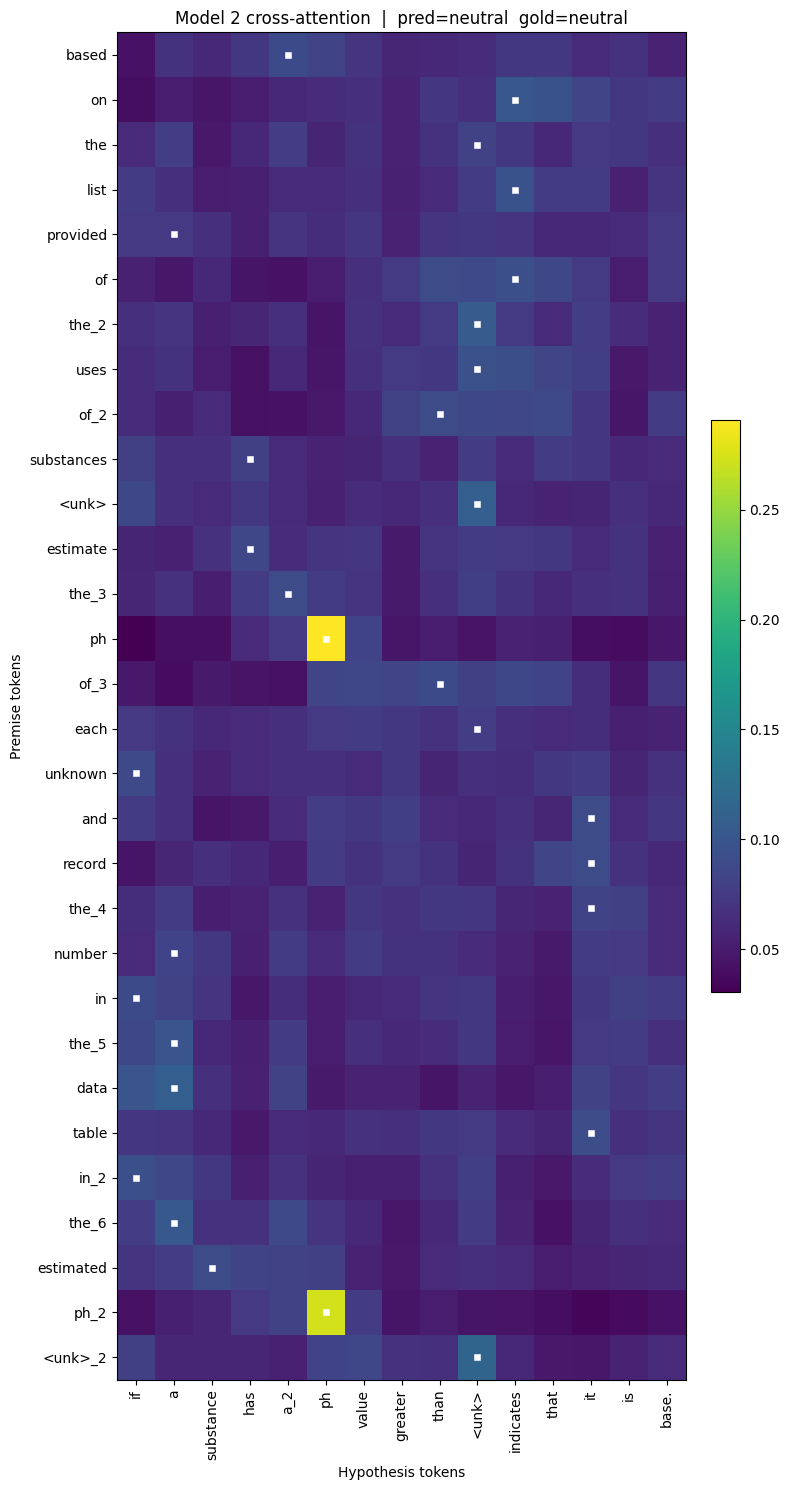

In [41]:
# ==== Attention visualization for Model 2 (cross-attention) ====
def ids_to_tokens(ids_1d, itos, pad_id):
    """Convert a 1D tensor of IDs to strings, trimming PAD."""
    out = []
    for i in ids_1d.tolist():
        if i == pad_id: break
        out.append(itos[i] if 0 <= i < len(itos) else "<unk>")
    return out

@torch.no_grad()
def compute_attention_matrix(model, p_ids, h_ids):
    """
    Recompute cross-attention inside Model 2 to get weights.
    Returns Ap (premise->hypothesis) of shape [B, Lp, Lh].
    """
    # Encode sides
    Hp, Mp = model.enc(p_ids)   # [B,Lp,D], [B,Lp] (bool)
    Hh, Mh = model.enc(h_ids)   # [B,Lh,D], [B,Lh] (bool)
    B, Lp, D = Hp.shape
    Lh = Hh.size(1)

    # Scores by attention kind
    kind = model.cross_attn_kind
    if kind == "dot":
        S = torch.bmm(Hp, Hh.transpose(1, 2)) / (D ** 0.5)
    elif kind == "bilinear":
        S = torch.bmm(model.xattn.W(Hp), Hh.transpose(1, 2)) / (D ** 0.5)
    else:  # additive
        Hp_ = model.xattn.Wp(Hp).unsqueeze(2).expand(B, Lp, Lh, D)
        Hh_ = model.xattn.Wh(Hh).unsqueeze(1).expand(B, Lp, Lh, D)
        S   = model.xattn.v(torch.tanh(Hp_ + Hh_)).squeeze(-1)  # [B,Lp,Lh]

    # Masking (keep only real tokens)
    S = S.masked_fill(~Mh[:, None, :], float('-inf'))
    S = S.masked_fill(~Mp[:, :, None], float('-inf'))

    # Normalize over hypothesis positions for each premise token
    Ap = torch.softmax(S, dim=-1)                                 # [B,Lp,Lh]
    Ap = torch.where(Mp[:, :, None], Ap, torch.zeros_like(Ap))    # zero rows for padded prem tokens
    return Ap

def _make_unique(tokens):
    """Append running indices to duplicate tokens: 'ph', 'ph' -> 'ph','ph_2'."""
    seen, out = {}, []
    for t in tokens:
        seen[t] = seen.get(t, 0) + 1
        out.append(f"{t}_{seen[t]}" if seen[t] > 1 else t)
    return out

@torch.no_grad()
def plot_model2_attention(viz_model, batch, itos, pad_id, id2label=None, example_index=0):
    p_ids, h_ids, y = batch
    device = next(viz_model.parameters()).device
    p_ids, h_ids, y = p_ids.to(device), h_ids.to(device), y.to(device)

    # Forward once to get prediction (for the title)
    logits = viz_model(p_ids, h_ids)
    pred = int(logits.argmax(1)[example_index].item())
    gold = int(y[example_index].item())
    if id2label is None:
        id2label = {0: "neutral", 1: "entails"}

    # Recompute attention weights
    Ap = compute_attention_matrix(viz_model, p_ids, h_ids)         # [B,Lp,Lh]
    A  = Ap[example_index].detach().cpu().numpy()                  # [Lp,Lh]

    # Token strings (trim at PAD)
    p_toks = ids_to_tokens(p_ids[example_index].detach().cpu(), itos, pad_id)
    h_toks = ids_to_tokens(h_ids[example_index].detach().cpu(), itos, pad_id)
    Lp_true, Lh_true = len(p_toks), len(h_toks)
    A = A[:Lp_true, :Lh_true]

    # Unique labels for repeated tokens (e.g., 'ph' twice)
    p_lab = _make_unique(p_toks)
    h_lab = _make_unique(h_toks)

    # Plot
    plt.figure(figsize=(max(8, Lh_true/2), max(6, Lp_true/2)))
    im = plt.imshow(A, aspect='auto')
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(Lh_true), h_lab, rotation=90)
    plt.yticks(range(Lp_true), p_lab)

    # Optional: mark max per row (white squares)
    row_argmax = A.argmax(axis=1)
    plt.scatter(row_argmax, np.arange(Lp_true), s=14, c='w', marker='s', linewidths=0.4)

    plt.title(f"Model 2 cross-attention  |  pred={id2label.get(pred,pred)}  gold={id2label.get(gold,gold)}")
    plt.xlabel("Hypothesis tokens"); plt.ylabel("Premise tokens")
    plt.tight_layout()
    plt.show()

# ---- pick a trained Model 2 and plot one batch ----
# Try to pick whichever variable exists: m2 (baseline), m2_bilin, or m2_nocomp
viz_model = None
for cand in ("m2", "m2_bilin", "m2_nocomp", "m2_main"):
    if cand in globals():
        viz_model = globals()[cand]; break
assert viz_model is not None, "Train Model 2 first (m2 / m2_bilin / m2_nocomp)."
viz_model.eval()

batch = next(iter(test_loader))
plot_model2_attention(viz_model, batch, ITOS, PAD_ID, id2label=ID2LABEL if 'ID2LABEL' in globals() else None)


### Cross-attention heatmap (Model 2) — Correct *neutral* prediction

The plot shows attention from each **premise** token (rows) to **hypothesis** tokens (columns). Brighter cells indicate stronger alignment. In this example the model predicts **neutral**, which matches the gold label.

**Key observations**

* **Strong local alignments:** Clear peaks on content words, especially **“ph” ↔ “ph”**, and nearby numeric/measurement terms.
* **Comparative cues checked:** Moderate focus on **“value / greater / than”**, showing the model looks for a comparative relation stated in the hypothesis.
* **Function words down-weighted:** Articles, prepositions, and stopwords are mostly dark, forming a sparse background.
* **No diagonal band:** Absence of a broad diagonal alignment (typical of paraphrase/entailment) indicates lack of sentence-level correspondence.
* **Decision fit:** Attention highlights shared topic (**pH**) without evidence for the rule “if pH > … then base,” supporting a **neutral** judgment.
* **White dots** mark each row’s top attention target.
* **Caveat:** Attention is a helpful diagnostic, not a definitive explanation of model reasoning.


## Object-Oriented Programming (OOP) in this Project

This codebase uses object-oriented design to keep model components modular and reusable. Each model (and several submodules) is a subclass of `torch.nn.Module`, with clear responsibilities and configurable behavior via constructor arguments.

**Implemented classes**
- **`BiLSTMEncoder`** — Sentence encoder with optional self-attention pooling (`attn_kind ∈ {None, "add", "dot", "mh"}`) and locked dropout.
- **`Model1_BiLSTM`** — Premise–hypothesis matcher that reuses two tied/untied encoders and classifies over `[p, h, |p−h|, p⊙h]`.
- **`GRUEncoder`** — Bidirectional GRU sentence encoder used by Model 2.
- **`CrossAttention`** — Token-wise cross-alignment (dot / bilinear / additive) between premise and hypothesis.
- **`Model2_GRU_ESIMlite`** — ESIM-style pipeline: cross-attention → enhancement/projection → (optional) composition GRU → pooling → classifier.
- **`PositionalEncoding`** — Sinusoidal position embeddings for the Transformer.
- **`TransformerNLI`** — Cross-encoder over `[premise] [SEP] [hypothesis]` with (optional) token-type embeddings and masked pooling.

**Why OOP here**
- **Modularity:** Encoders, attention, and classifiers are swappable without touching training code.
- **Ablations by configuration:** Attention type, pooling, and composition GRU are toggled via flags, not rewritten code.
- **Reusability:** The same training loop runs any `nn.Module` with the same `(p_ids, h_ids) → logits` interface.

**Where to find the classes**
- Model 1: Section **2.2**
- Model 2: Section **2.3**
- Model 3: Section **2.4**
